In [45]:
import pandas as pd

dataPath = "/Users/xingliu/Downloads/ML4T Course/Env/ML4T_2026Spring/data/"

df = pd.read_csv(dataPath + "IBM.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2012-09-12,203.52,204.65,202.96,203.77,3284000,203.77
1,2012-09-11,200.55,203.46,200.51,203.27,3910600,203.27
2,2012-09-10,199.39,201.82,198.73,200.95,4208000,200.95
3,2012-09-07,199.12,199.50,198.08,199.50,3413700,199.50
4,2012-09-06,196.26,199.46,196.11,199.10,3931700,199.10


In [46]:
#Note: Adjusted close accounts for the dividends and splits etc so it's what you would've gotten if you just held the stock.
#Close just tells you the number and any close info is not reflected


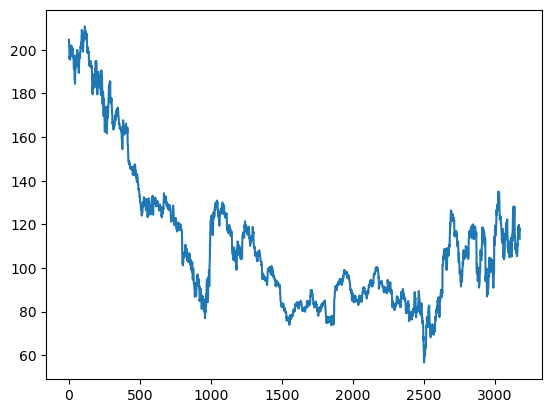

In [47]:
import matplotlib.pyplot as plt
df["High"].plot()
plt.show()

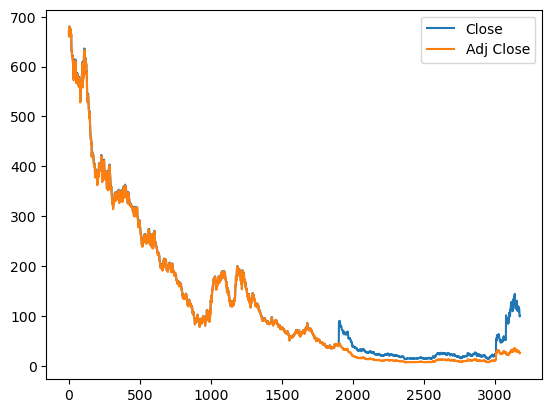

In [48]:
df=pd.read_csv(dataPath + "AAPL.csv")
df[["Close", "Adj Close"]].plot()
plt.show()

In [49]:
startDate = '2010-01-22'
endDate = '2010-01-26'
dates = pd.date_range(startDate, endDate)
print(dates)
print(dates[0])

DatetimeIndex(['2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25',
               '2010-01-26'],
              dtype='datetime64[ns]', freq='D')
2010-01-22 00:00:00


In [50]:
df1=pd.DataFrame(index=dates)
print(df1)
dfSPY = pd.read_csv(dataPath+'SPY.csv',index_col="Date", parse_dates=True, usecols=['Date','Adj Close'],na_values=['nan'])
df1 = df1.join(dfSPY)
df1 = df1.dropna()
print(df1)

Empty DataFrame
Columns: []
Index: [2010-01-22 00:00:00, 2010-01-23 00:00:00, 2010-01-24 00:00:00, 2010-01-25 00:00:00, 2010-01-26 00:00:00]
            Adj Close
2010-01-22     104.34
2010-01-25     104.87
2010-01-26     104.43


In [51]:
df1=pd.DataFrame(index=dates)
print(df1)
dfSPY = pd.read_csv(dataPath+'SPY.csv',index_col="Date", parse_dates=True, usecols=['Date','Adj Close'],na_values=['nan'])
dfSPY= dfSPY.rename(columns={'Adj Close':'SPY'})
df1 = df1.join(dfSPY, how='inner')
print(df1)

Empty DataFrame
Columns: []
Index: [2010-01-22 00:00:00, 2010-01-23 00:00:00, 2010-01-24 00:00:00, 2010-01-25 00:00:00, 2010-01-26 00:00:00]
               SPY
2010-01-22  104.34
2010-01-25  104.87
2010-01-26  104.43


In [52]:
symbols=['GOOG','IBM','GLD']
for symbol in symbols:
    df_temp = pd.read_csv("{}{}.csv".format(dataPath,symbol),index_col='Date',parse_dates=True,usecols=['Date','Adj Close'],na_values=['nanN'])
    df_temp=df_temp.rename(columns={'Adj Close': symbol})
    df1=df1.join(df_temp)
print(df1)

               SPY    GOOG     IBM     GLD
2010-01-22  104.34  550.01  119.61  107.17
2010-01-25  104.87  540.00  120.20  107.48
2010-01-26  104.43  542.42  119.85  107.56


In [53]:
#Utility Functions
import os
def symbol_to_path(symbol, base_dir="data"):
    return os.path.join(dataPath, "{}.csv".format(str(symbol)))

def get_data(symbols, dates):
    df=pd.DataFrame(index=dates)
    if 'SPY' not in symbols:
        symbols.insert(0, 'SPY')
    for symbol in symbols:
        df_temp =pd.read_csv(symbol_to_path(symbol),index_col='Date',parse_dates=True, usecols=['Date','Adj Close'], na_values=['nan'])
        df_temp=df_temp.rename(columns={'Adj Close': symbol})
        df=df.join(df_temp)
        if symbol=='SPY':
            df=df.dropna(subset=["SPY"])
    return df

In [54]:
dates = pd.date_range('2010-01-01','2010-12-31')
df1 = get_data(symbols,dates)
print(df1)

               SPY    GOOG     IBM     GLD
2010-01-04  108.27  626.75  126.24  109.80
2010-01-05  108.56  623.99  124.71  109.70
2010-01-06  108.64  608.26  123.90  111.51
2010-01-07  109.10  594.10  123.47  110.82
2010-01-08  109.46  602.02  124.71  111.37
...            ...     ...     ...     ...
2010-12-27  121.90  602.38  141.17  135.02
2010-12-28  122.07  598.92  141.53  137.22
2010-12-29  122.16  601.00  142.32  137.71
2010-12-30  121.97  598.86  142.46  137.03
2010-12-31  122.00  593.97  142.55  138.72

[252 rows x 4 columns]


In [55]:
print(df1.loc['2010-01-27':'2010-01-30',['SPY','IBM']])

               SPY     IBM
2010-01-27  104.93  120.40
2010-01-28  103.73  117.94
2010-01-29  102.60  116.65


<Axes: >

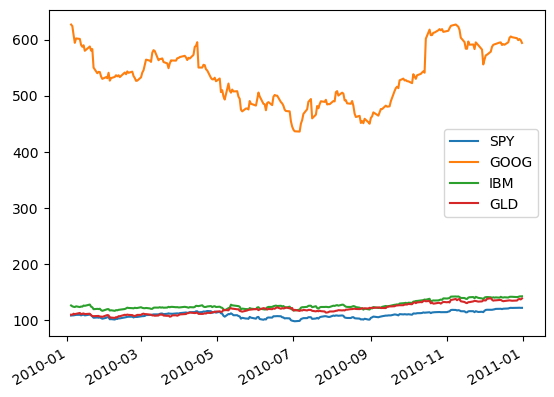

In [56]:
df1.plot()

In [57]:
def plot_data(df, title="Stock prices"):
    ax=df.plot(title=title, fontsize=10)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    plt.show()

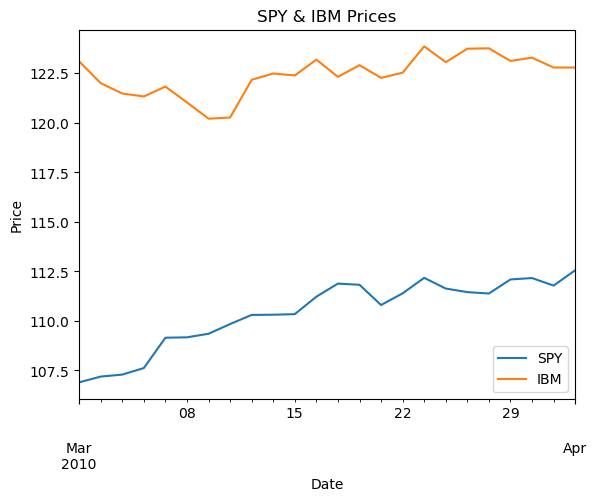

In [58]:
plot_data(df1.loc["03/01/2010":"04/01/2010",['SPY','IBM']], title="SPY & IBM Prices")

In [66]:
def normalize_data(df):
    return df/df.iloc[0,:]    

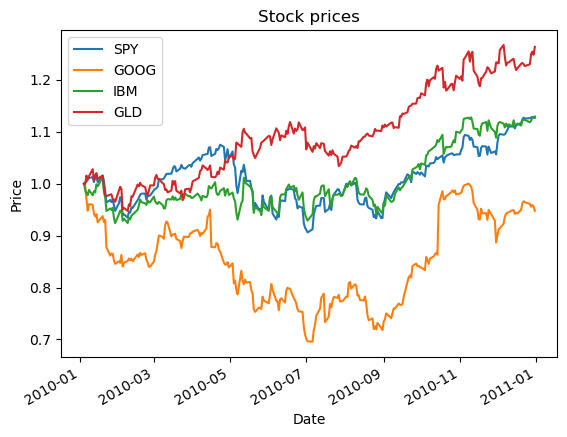

In [67]:
df1.iloc[0,:].head()
plot_data(normalize_data(df1))

In [ ]:
# To read multiple stocks into a single dataframe, you need to:

# Specify a set of dates using pandas.date_range
# Create an empty dataframe with dates as index 
# This helps align stock data and orders it by trading date
# Read in a reference stock (here SPY) and drop non-trading days using pandas.DataFrame.dropna
# Incrementally join dataframes using pandas.DataFrame.join
# Once you have multiple stocks, you can:

# Select a subset of stocks by ticker symbols
# Slice by row (dates) and column (symbols)
# Plot multiple stocks at once (still using pandas.DataFrame.plot)
# Carry out arithmetic operations across stocks, e.g. normalize by the first day's price